In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('data/engineered_movies_dataset.csv')

Which genre is the safest bet for a new filmmaker

### Goal: Find out which genres yield the highest Return on Investment (ROI).

C:\Users\ANISH\AppData\Local\Temp\ipykernel_38276\1967218719.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_roi.values, y=genre_roi.index, palette="viridis")


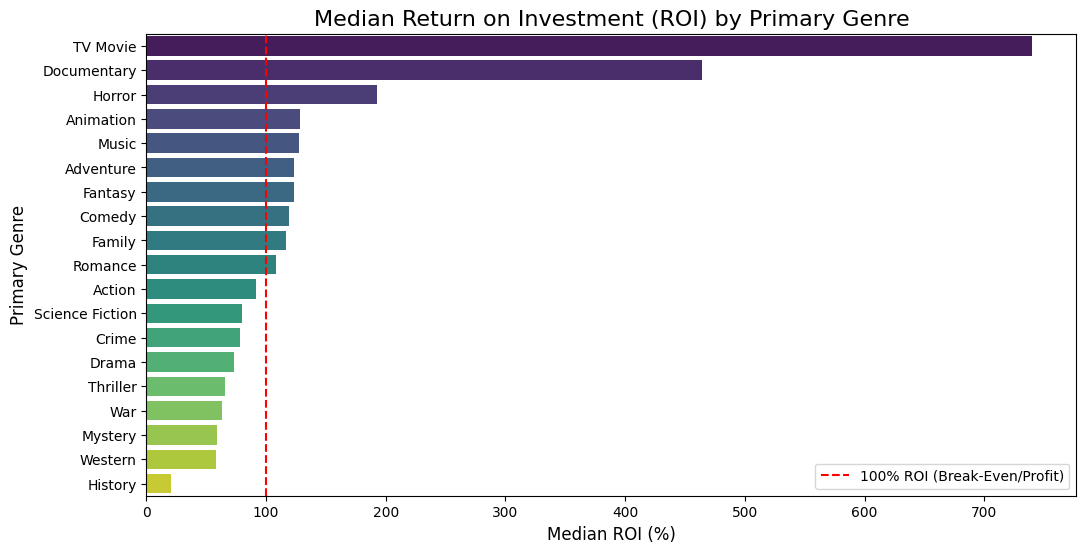

In [4]:
plt.figure(figsize=(12, 6))

# Calculate the median ROI for each primary genre
genre_roi = df.groupby('primary_genre')['roi_percentage'].median().sort_values(ascending=False)


# Bar chart
sns.barplot(x=genre_roi.values, y=genre_roi.index, palette="viridis")
plt.title('Median Return on Investment (ROI) by Primary Genre', fontsize=16)
plt.xlabel('Median ROI (%)', fontsize=12)
plt.ylabel('Primary Genre', fontsize=12)
plt.axvline(x=100, color='red', linestyle='--', label='100% ROI (Break-Even/Profit)')
plt.legend()
plt.show()

What is the optimal movie length?
### Goal: See if movie runtime affects the audience's rating (`vote_average`).

C:\Users\ANISH\AppData\Local\Temp\ipykernel_38276\761213579.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='runtime_category', y='vote_average', data=df, palette="Set2", order=labels)


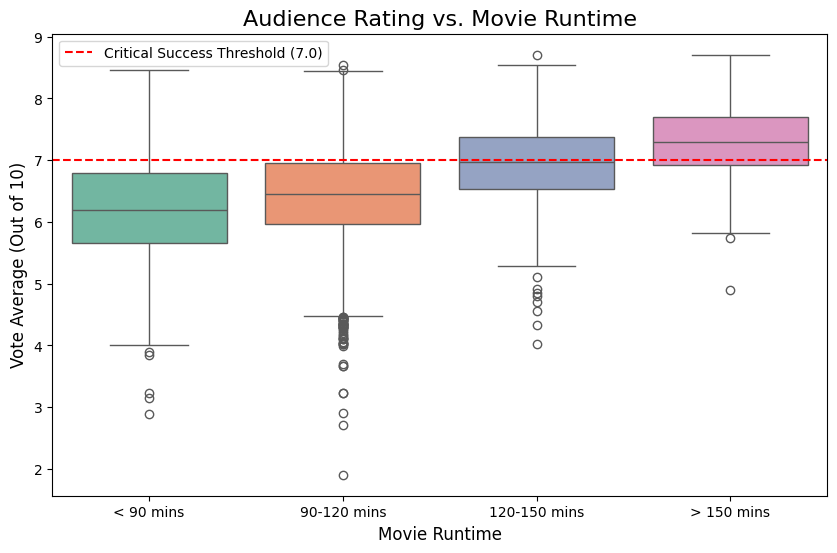

In [ ]:
plt.figure(figsize=(10, 6))

# Let's group runtime into categories (bins) for cleaner visualization
bins =[0, 90, 120, 150, df['runtime'].max()]
labels =['< 90 mins', '90-120 mins', '120-150 mins', '> 150 mins']
df['runtime_category'] = pd.cut(df['runtime'], bins=bins, labels=labels)

sns.boxplot(x='runtime_category', y='vote_average', data=df, palette="Set2", order=labels)
plt.title('Audience Rating vs. Movie Runtime', fontsize=16)
plt.xlabel('Movie Runtime', fontsize=12)
plt.ylabel('Vote Average (Out of 10)', fontsize=12)
plt.axhline(y=7.0, color='red', linestyle='--', label='Critical Success Threshold (7.0)')
plt.legend()
plt.show()



When is the best time to release a movie?
### Goal: Find out which months produce the most "Sweet Spot" movies (High ROI + High Rating).

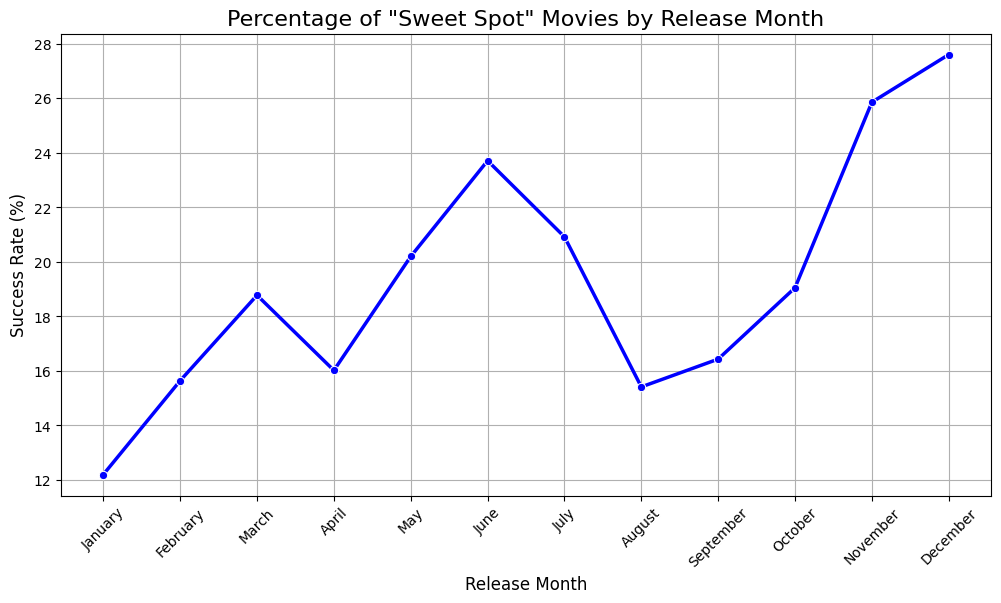

In [6]:
plt.figure(figsize=(12, 6))

months_order =['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']

# Calculate percentage of movies released in each month that hit the "Sweet Spot"
sweet_spot_rates = df.groupby('release_month')['is_sweet_spot'].mean() * 100
sweet_spot_rates = sweet_spot_rates.reindex(months_order)

sns.lineplot(x=sweet_spot_rates.index, y=sweet_spot_rates.values, marker='o', color='b', linewidth=2.5)
plt.title('Percentage of "Sweet Spot" Movies by Release Month', fontsize=16)
plt.xlabel('Release Month', fontsize=12)
plt.ylabel('Success Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Insight for report: Look for peaks. Summer (June/July) and Holidays (Nov/Dec) are usually highest.

The Reality Check (Correlation Matrix)
### Goal: Does a bigger budget actually mean a better movie?

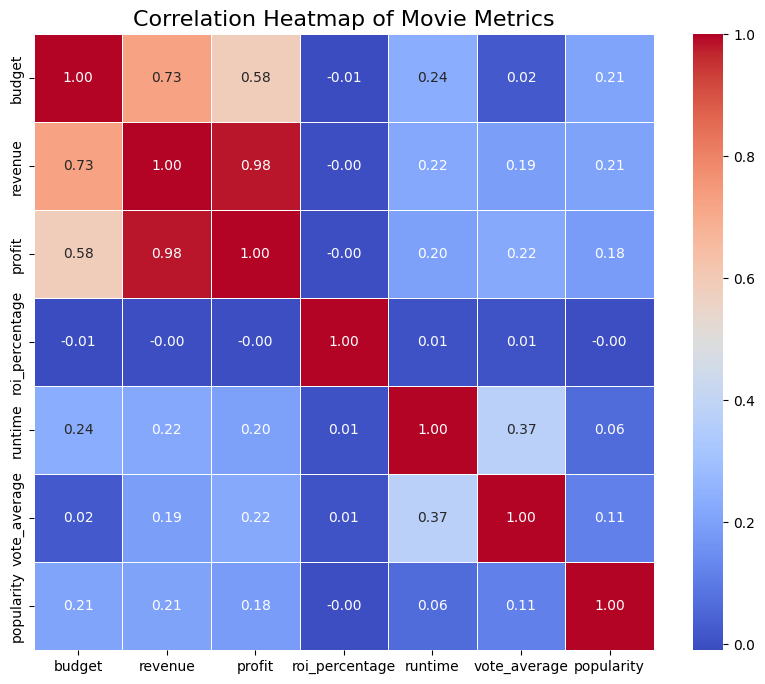

In [ ]:
plt.figure(figsize=(10, 8))

# Select only our numeric columns for correlation
numeric_cols =['budget', 'revenue', 'profit', 'roi_percentage', 'runtime', 'vote_average', 'popularity']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Movie Metrics', fontsize=16)
plt.show()


Does spending more guarantee more money?
### Goal: Visualize the direct relationship between Budget and Revenue, colored by whether the movie was a success.

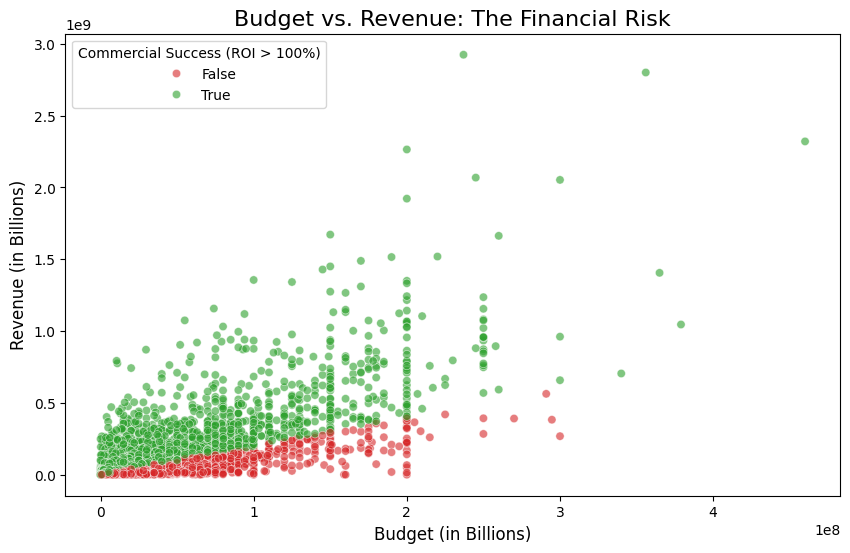

In [8]:
plt.figure(figsize=(10, 6))

# Plotting Budget vs Revenue
sns.scatterplot(
    x='budget', 
    y='revenue', 
    hue='is_commercial_success', 
    palette={True: '#2ca02c', False: '#d62728'}, # Green for success, Red for failure
    alpha=0.6, # Transparency to see overlapping dots
    data=df
)

plt.title('Budget vs. Revenue: The Financial Risk', fontsize=16)
plt.xlabel('Budget (in Billions)', fontsize=12)
plt.ylabel('Revenue (in Billions)', fontsize=12)
plt.legend(title='Commercial Success (ROI > 100%)')
plt.show()

# Insight: You will likely see a massive cluster of dots at the bottom left. 
# This proves that low-budget movies frequently achieve commercial success (green dots), 
# while high-budget movies are a massive gamble.

### Goal: Show the distribution (spread) of all movie ratings to understand the "average" landscape.

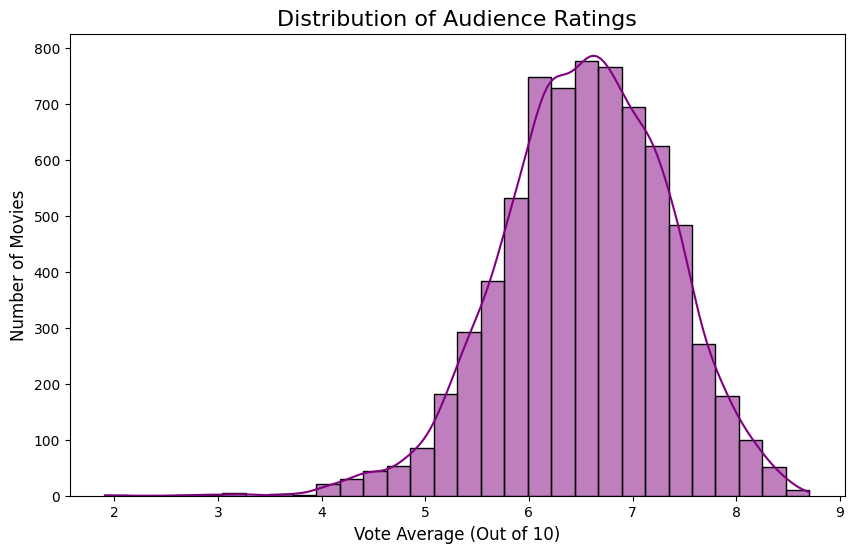

In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(df['vote_average'], bins=30, kde=True, color='purple')

plt.title('Distribution of Audience Ratings', fontsize=16)
plt.xlabel('Vote Average (Out of 10)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.show()


Which day of the week is best for a premiere?

C:\Users\ANISH\AppData\Local\Temp\ipykernel_38276\2554897556.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='release_day', y='profit', data=df_filtered, order=days_order, palette="muted", inner="quartile")


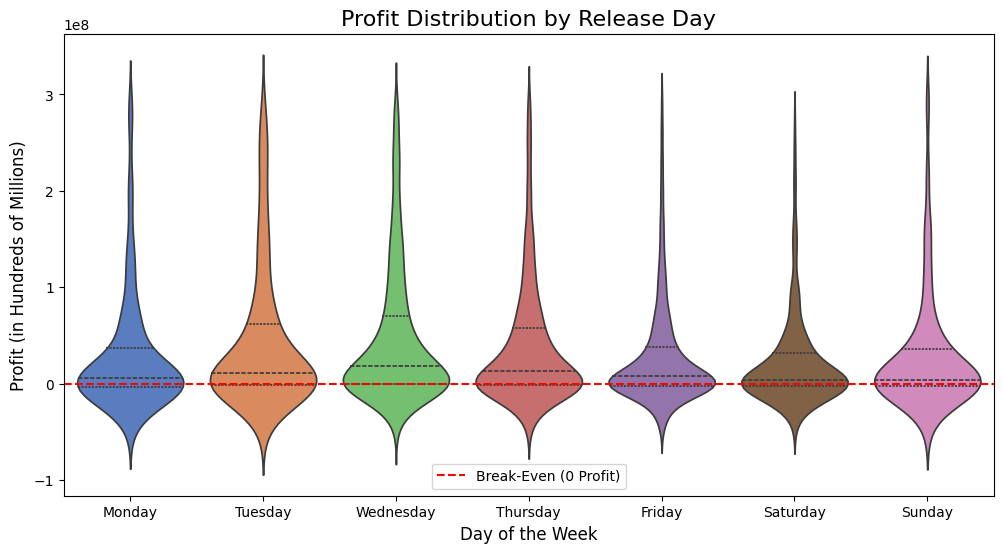

In [ ]:
plt.figure(figsize=(12, 6))

days_order =['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


sns.violinplot(x='release_day', y='profit', data=df_filtered, order=days_order, palette="muted", inner="quartile")

plt.title('Profit Distribution by Release Day', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Profit (in Hundreds of Millions)', fontsize=12)
plt.axhline(y=0, color='red', linestyle='--', label='Break-Even (0 Profit)')
plt.legend()
plt.show()

# Insight: Fridays and Thursdays usually have the widest "bellies" (density) in the positive profit range, 
# meaning they are the standard, safest days to release.

### Goal: Show the exact proportion of movies that actually achieve our "Sweet Spot" criteria vs those that fail.

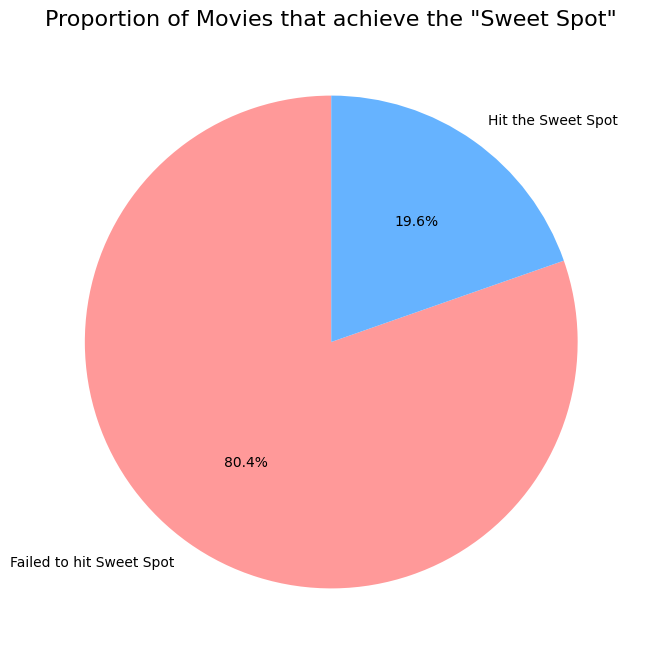

In [ ]:
plt.figure(figsize=(8, 8))

# Count how many movies hit the sweet spot
sweet_spot_counts = df['is_sweet_spot'].value_counts()

# Labels and colors
labels =['Failed to hit Sweet Spot', 'Hit the Sweet Spot']
colors =['#ff9999','#66b3ff']

plt.pie(sweet_spot_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)


plt.title('Proportion of Movies that achieve the "Sweet Spot"', fontsize=16)
plt.show()

# Insight: This visualizes the brutal reality. Usually, less than 20% of movies hit 
# both high ROI and high Ratings. This emphasizes why your playbook is needed!

### Goal: Find out if popularity score (social buzz/trending) actually leads to higher revenue or if it's just noise.

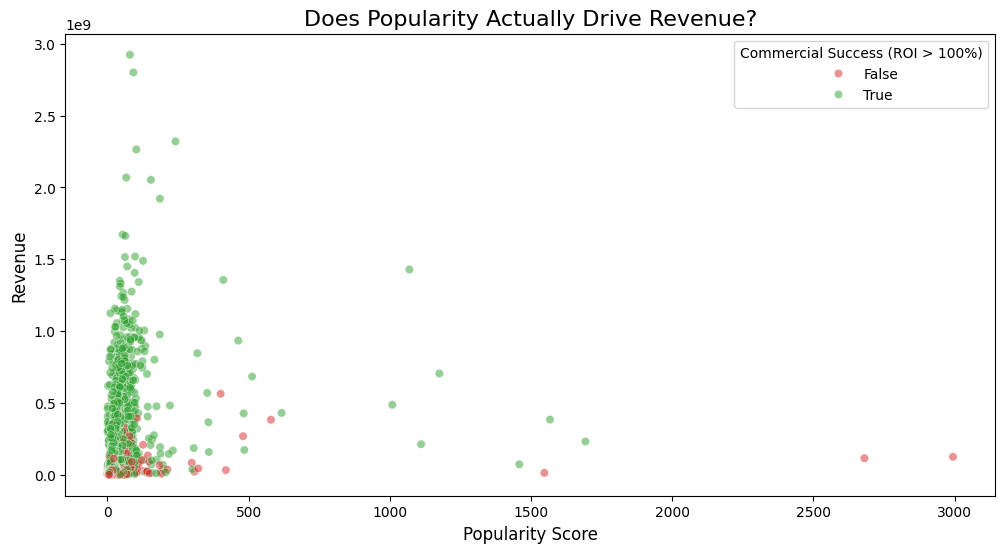

In [2]:
plt.figure(figsize=(12, 6))

sns.scatterplot(x='popularity', y='revenue', hue='is_commercial_success',
                palette={True: '#2ca02c', False: '#d62728'}, alpha=0.5, data=df)

plt.title('Does Popularity Actually Drive Revenue?', fontsize=16)
plt.xlabel('Popularity Score', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.legend(title='Commercial Success (ROI > 100%)')
plt.show()

### Goal: Find out if movies that mix multiple genres earn a better ROI than single-genre films.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_22592\2311454746.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_roi.index, y=genre_roi.values, palette='viridis')


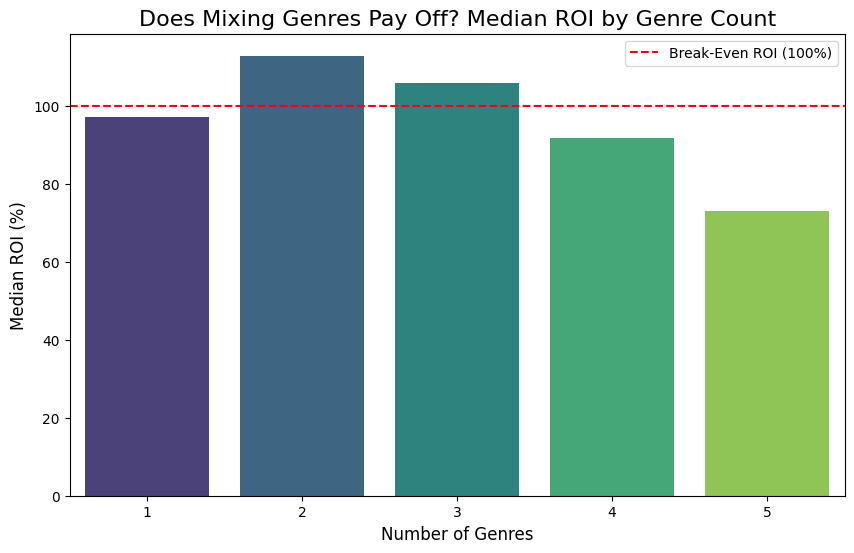

In [3]:
plt.figure(figsize=(10, 6))

df['genre_count_capped'] = df['genre_count'].clip(upper=5)
genre_roi = df.groupby('genre_count_capped')['roi_percentage'].median()

sns.barplot(x=genre_roi.index, y=genre_roi.values, palette='viridis')
plt.axhline(y=100, color='red', linestyle='--', label='Break-Even ROI (100%)')
plt.title('Does Mixing Genres Pay Off? Median ROI by Genre Count', fontsize=16)
plt.xlabel('Number of Genres', fontsize=12)
plt.ylabel('Median ROI (%)', fontsize=12)
plt.legend()
plt.show()

### Goal: Identify the top production companies by number of Sweet Spot films they have produced.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_22592\1854820283.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.values, y=top_companies.index, palette='Blues_r')


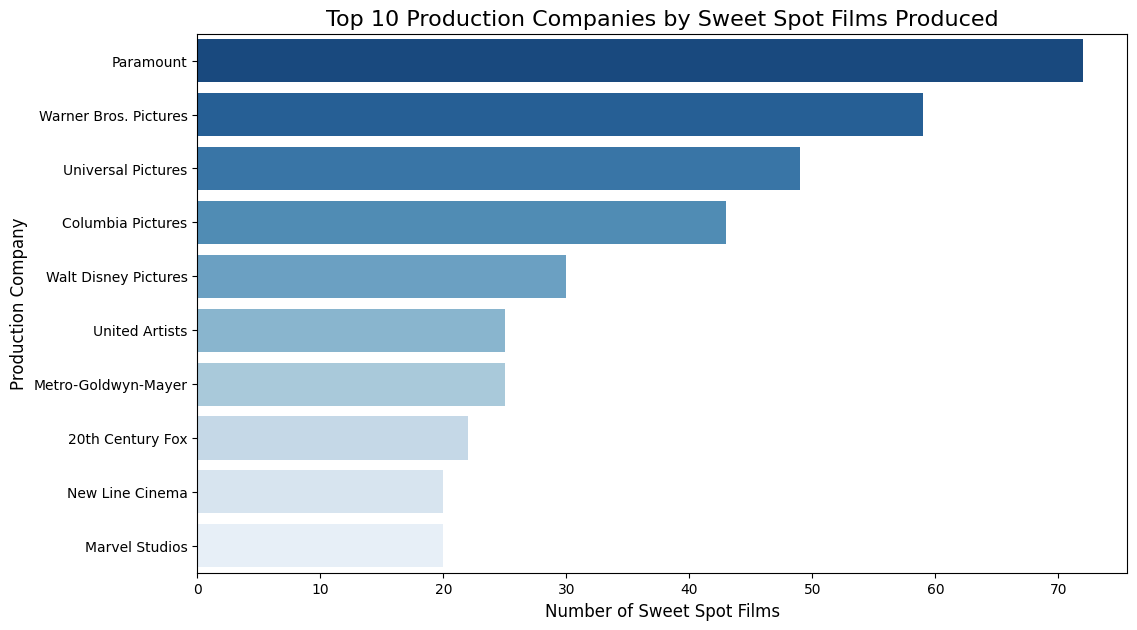

In [4]:
plt.figure(figsize=(12, 7))

df['first_company'] = df['production_companies'].apply(
    lambda x: str(x).split(',')[0].strip() if pd.notnull(x) else 'Unknown')

top_companies = (df[df['is_sweet_spot'] == True]
                 .groupby('first_company')['is_sweet_spot']
                 .count()
                 .sort_values(ascending=False)
                 .head(10))

sns.barplot(x=top_companies.values, y=top_companies.index, palette='Blues_r')
plt.title('Top 10 Production Companies by Sweet Spot Films Produced', fontsize=16)
plt.xlabel('Number of Sweet Spot Films', fontsize=12)
plt.ylabel('Production Company', fontsize=12)
plt.show()

### Goal: Track how average movie revenue has changed across decades to show future filmmakers the market they are entering.

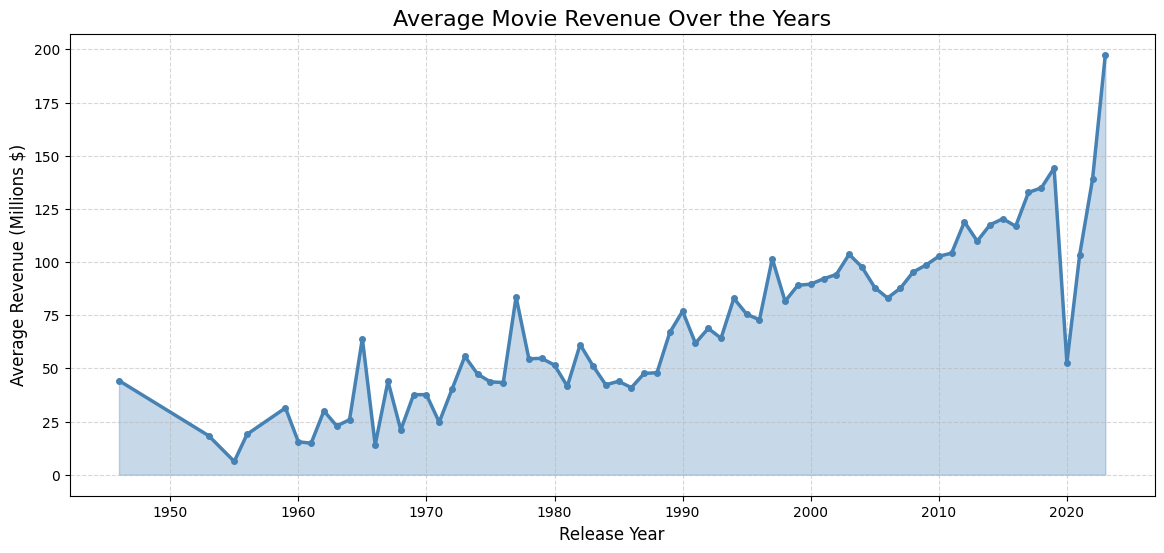

In [5]:
plt.figure(figsize=(14, 6))

valid_years = df['release_year'].value_counts()[df['release_year'].value_counts() >= 10].index
yearly_avg = df[df['release_year'].isin(valid_years)].groupby('release_year')['revenue'].mean() / 1e6

plt.fill_between(yearly_avg.index, yearly_avg.values, alpha=0.3, color='steelblue')
plt.plot(yearly_avg.index, yearly_avg.values, color='steelblue', linewidth=2.5, marker='o', markersize=4)
plt.title('Average Movie Revenue Over the Years', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Average Revenue (Millions $)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Goal: Explore whether movies with more votes (larger audience engagement) tend to have higher ratings or if niche films with few votes can dominate the top scores.

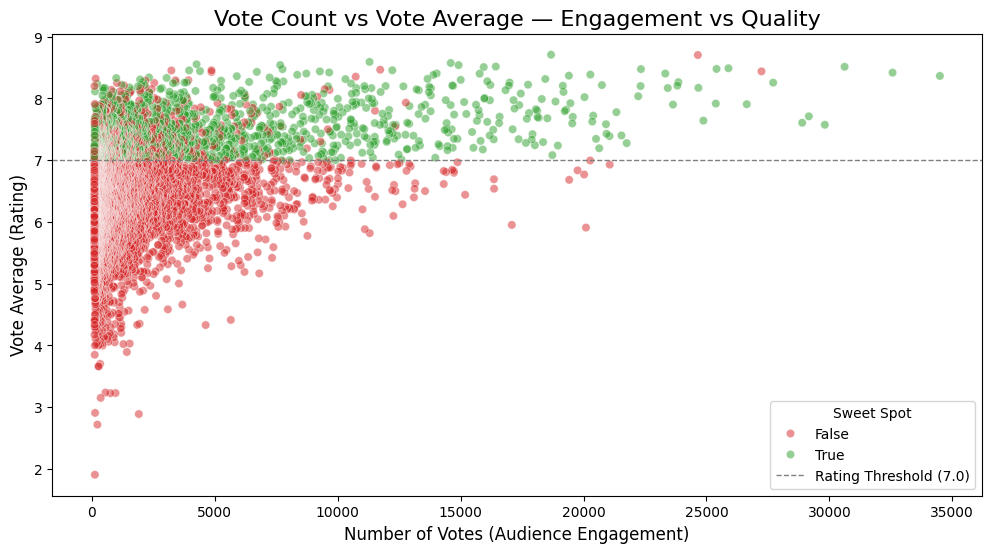

In [6]:
plt.figure(figsize=(12, 6))

sns.scatterplot(x='vote_count', y='vote_average', hue='is_sweet_spot',
                palette={True: '#2ca02c', False: '#d62728'}, alpha=0.5, data=df)

plt.axhline(y=7.0, color='gray', linestyle='--', linewidth=1, label='Rating Threshold (7.0)')
plt.title('Vote Count vs Vote Average — Engagement vs Quality', fontsize=16)
plt.xlabel('Number of Votes (Audience Engagement)', fontsize=12)
plt.ylabel('Vote Average (Rating)', fontsize=12)
plt.legend(title='Sweet Spot')
plt.show()

### Goal: Directly plot rating against profit to reveal whether critical acclaim and financial success actually go hand in hand or are completely independent.

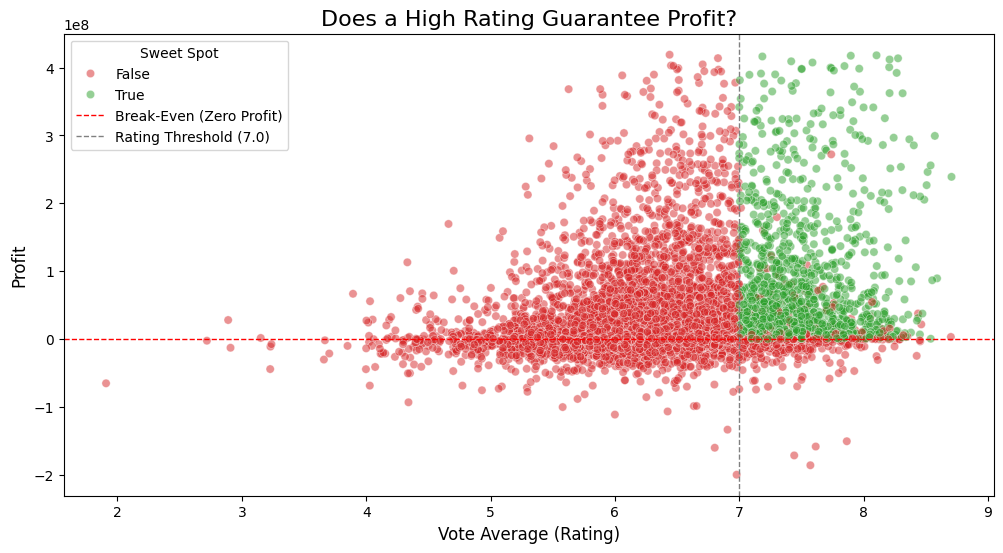

In [7]:
plt.figure(figsize=(12, 6))

df_filtered = df[df['profit'].abs() < df['profit'].quantile(0.97)]

sns.scatterplot(x='vote_average', y='profit', hue='is_sweet_spot',
                palette={True: '#2ca02c', False: '#d62728'}, alpha=0.5, data=df_filtered)

plt.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Break-Even (Zero Profit)')
plt.axvline(x=7.0, color='gray', linestyle='--', linewidth=1, label='Rating Threshold (7.0)')
plt.title('Does a High Rating Guarantee Profit?', fontsize=16)
plt.xlabel('Vote Average (Rating)', fontsize=12)
plt.ylabel('Profit', fontsize=12)
plt.legend(title='Sweet Spot')
plt.show()

### Goal: Compare the average profile of Sweet Spot films vs non-Sweet Spot films across budget, revenue, popularity, rating, and runtime to build the blueprint of a successful film.

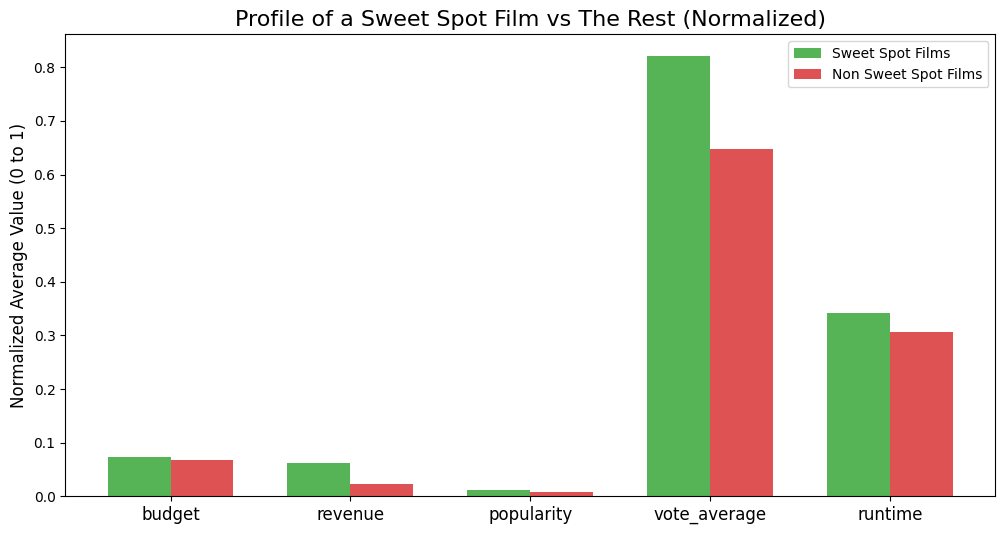

In [8]:
plt.figure(figsize=(12, 6))

metrics = ['budget', 'revenue', 'popularity', 'vote_average', 'runtime']
sweet = df[df['is_sweet_spot'] == True][metrics].mean()
not_sweet = df[df['is_sweet_spot'] == False][metrics].mean()

sweet_norm = (sweet - df[metrics].min()) / (df[metrics].max() - df[metrics].min())
not_sweet_norm = (not_sweet - df[metrics].min()) / (df[metrics].max() - df[metrics].min())

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, sweet_norm.values, width, label='Sweet Spot Films', color='#2ca02c', alpha=0.8)
plt.bar(x + width/2, not_sweet_norm.values, width, label='Non Sweet Spot Films', color='#d62728', alpha=0.8)

plt.xticks(x, metrics, fontsize=12)
plt.title('Profile of a Sweet Spot Film vs The Rest (Normalized)', fontsize=16)
plt.ylabel('Normalized Average Value (0 to 1)', fontsize=12)
plt.legend()
plt.show()